# RoBERTa PCL Detection

Just oversample the minority PCL class by 8x


In [1]:
!pip install contractions python-dotenv huggingface_hub

In [2]:
import os
import re
import random

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


/home/wowthecoder/imperial-nlp-cw/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
# Local auth: load Hugging Face token from .env
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print('HF token loaded from .env and login completed.')
else:
    print('HF_TOKEN not found in .env; proceeding without explicit login.')


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded from .env and login completed.


In [4]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME = 'roberta-base'
RUN_NAME = 'checkpoints/oversampling'
MAX_LENGTH = 256

DATA_ROOT='..'
TSV_PATH       = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')

os.makedirs(RUN_NAME, exist_ok=True)

print(f'RUN_NAME  : {RUN_NAME}')


RUN_NAME  : checkpoints/oversampling


In [5]:
def load_task1(tsv_path: str) -> pd.DataFrame:
    """Load labelled PCL dataset; binarise labels (0/1 -> 0, 2/3/4 -> 1)."""
    rows = []
    with open(tsv_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue
            orig_label = parts[-1]
            rows.append({
                'par_id':  str(parts[0]),
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
                'label':   0 if orig_label in {'0', '1'} else 1,
            })
    return pd.DataFrame(rows)

In [6]:
# ============================================================
# Load + preprocess data (local module)
# ============================================================
df = load_task1(TSV_PATH)

def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    return text

df['clean_text'] = df['text'].apply(preprocess_text)

# Include keyword and country in model input text.
df['keyword'] = df['keyword'].fillna('').astype(str)
df['country'] = df['country'].fillna('').astype(str)
df['model_text'] = df['keyword'].str.strip() + ' </s> ' + df['country'].str.strip() + ' </s> ' + df['clean_text'].str.strip()

print(f'Loaded dataset: {len(df):,} samples')
print(df['label'].value_counts().sort_index().rename({0: 'No-PCL', 1: 'PCL'}))



Loaded dataset: 10,469 samples
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Official Train/Dev split + Oversampling
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df = pd.read_csv(DEV_IDS_PATH, dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids = set(dev_ids_df['par_id'].astype(str))

train_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)
dev_df = df[df['par_id'].isin(dev_par_ids)].copy().reset_index(drop=True)

leftover_df = df[~df['par_id'].isin(train_par_ids | dev_par_ids)].copy().reset_index(drop=True)
if len(leftover_df) > 0:
    train_df = pd.concat([train_df, leftover_df], ignore_index=True)
    print(f'Appended {len(leftover_df):,} unassigned samples to training set.')


def describe_split(name: str, frame: pd.DataFrame):
    n = len(frame)
    n_pcl = int((frame['label'] == 1).sum())
    n_no_pcl = int((frame['label'] == 0).sum())
    ratio = f'1:{(n_no_pcl / n_pcl):.1f}' if n_pcl > 0 else 'undefined'
    print(f'{name:<16} -> total={n:,} | PCL={n_pcl:,} | No-PCL={n_no_pcl:,} | ratio={ratio}')


describe_split('Train (before OS)', train_df)
describe_split('Dev', dev_df)

replicated_pcls = pd.concat([train_df[train_df['label'] == 1]] * 8, ignore_index=True)
train_df = pd.concat([train_df, replicated_pcls], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

describe_split('Train (after OS)', train_df)


Train (before OS) -> total=8,375 | PCL=794 | No-PCL=7,581 | ratio=1:9.5
Dev              -> total=2,094 | PCL=199 | No-PCL=1,895 | ratio=1:9.5
Train (after OS) -> total=14,727 | PCL=7,146 | No-PCL=7,581 | ratio=1:1.1


In [8]:
# ============================================================
# Tokenization + Hugging Face Datasets
# ============================================================
train_hf = Dataset.from_pandas(
    train_df[['model_text', 'label']].rename(columns={'model_text': 'text'}),
    preserve_index=False,
)
dev_hf = Dataset.from_pandas(
    dev_df[['model_text', 'label']].rename(columns={'model_text': 'text'}),
    preserve_index=False,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


train_ds = train_hf.map(tokenize, batched=True, remove_columns=['text'])
dev_ds = dev_hf.map(tokenize, batched=True, remove_columns=['text'])

train_ds = train_ds.rename_column('label', 'labels')
dev_ds = dev_ds.rename_column('label', 'labels')

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dev_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print(train_ds)
print(dev_ds)



Map: 100%|██████████| 2094/2094 [00:00<00:00, 27174.73 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 14727
})
Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2094
})


In [9]:
# ============================================================
# Metrics (macro-F1 focused)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "f1_pcl": f1_score(labels, preds, average="binary", pos_label=1, zero_division=0),
        "precision_pcl": precision_score(labels, preds, average="binary", pos_label=1, zero_division=0),
        "recall_pcl": recall_score(labels, preds, average="binary", pos_label=1, zero_division=0),
    }



In [ ]:
# ============================================================
# Model + TrainingArguments + Trainer
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

# Same core training setup as the example notebook, with batch size=4.
training_args = TrainingArguments(
    RUN_NAME,
    num_train_epochs=2,
    save_total_limit=2,
    learning_rate=1e-5,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    metric_for_best_model="f1_pcl",
    greater_is_better=True,
    load_best_model_at_end=True,
    warmup_steps=400,
    eval_delay=1000,
    report_to='none',
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.001)],
)

print('Trainer configured.')


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 513.32it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Trainer configured.


In [11]:
train_result = trainer.train()
train_result


Step,Training Loss,Validation Loss,F1 Pcl,Precision Pcl,Recall Pcl
1000,0.601127,0.593376,0.461538,0.335616,0.738693
1500,0.498726,0.770558,0.463215,0.317757,0.854271
2000,0.417855,0.503414,0.551852,0.436950,0.748744
2500,0.338857,0.516378,0.558824,0.440580,0.763819
3000,0.318229,0.543746,0.566191,0.476027,0.698492
3500,0.281815,0.502456,0.571429,0.580311,0.562814
4000,0.174162,0.695011,0.540643,0.433333,0.718593
4500,0.147132,0.543253,0.577878,0.524590,0.643216
5000,0.095411,0.620903,0.580645,0.507519,0.678392
5500,0.123390,0.646386,0.580645,0.507519,0.678392


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.53s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=7364, training_loss=0.2674563919183419, metrics={'train_runtime': 613.3403, 'train_samples_per_second': 48.022, 'train_steps_per_second': 12.006, 'total_flos': 1501447862410860.0, 'train_loss': 0.2674563919183419, 'epoch': 2.0})

In [12]:
eval_metrics = trainer.evaluate()
print('Evaluation metrics:')
for k, v in eval_metrics.items():
    if isinstance(v, (int, float)):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Evaluation metrics:
  eval_loss: 0.6027
  eval_f1_pcl: 0.6050
  eval_precision_pcl: 0.5492
  eval_recall_pcl: 0.6734
  eval_runtime: 7.8592
  eval_samples_per_second: 266.4390
  eval_steps_per_second: 66.6730
  epoch: 2.0000


              precision    recall  f1-score   support

      No-PCL     0.9649    0.9420    0.9533      1895
         PCL     0.5492    0.6734    0.6050       199

    accuracy                         0.9164      2094
   macro avg     0.7570    0.8077    0.7791      2094
weighted avg     0.9254    0.9164    0.9202      2094



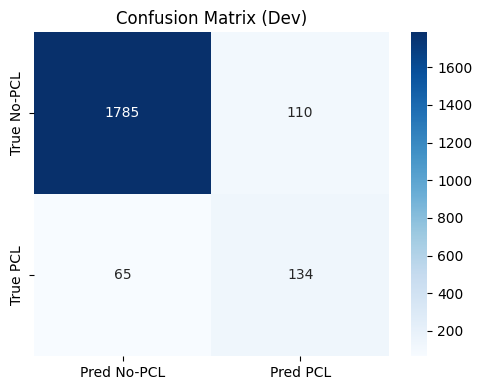

In [13]:
# ============================================================
# Detailed evaluation report
# ============================================================
pred_output = trainer.predict(dev_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred No-PCL', 'Pred PCL'],
    yticklabels=['True No-PCL', 'True PCL'],
)
plt.title('Confusion Matrix (Dev)')
plt.tight_layout()
plt.show()


In [14]:
BEST_MODEL_DIR = os.path.join(RUN_NAME, 'best')
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f'Saved best model and tokenizer to: {BEST_MODEL_DIR}')


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.22s/it]

Saved best model and tokenizer to: checkpoints/oversampling/best
